In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("juhibhojani/house-price")

# print("Path to dataset files:", path)

In [2]:
data_set_link = 'https://www.kaggle.com/datasets/juhibhojani/house-price'

### Import Libraries

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Using device: cpu
PyTorch version: 2.12.1+cpu


### Loading Data Frame

In [4]:
df = pd.read_csv('house_prices.csv')

In [5]:
df.shape

(187531, 21)

In [6]:
df.columns.to_list()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

In [7]:
df.isna().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [8]:
df.dtypes

Index                  int64
Title                    str
Description              str
Amount(in rupees)        str
Price (in rupees)    float64
location                 str
Carpet Area              str
Status                   str
Floor                    str
Transaction              str
Furnishing               str
facing                   str
overlooking              str
Society                  str
Bathroom                 str
Balcony                  str
Car Parking              str
Ownership                str
Super Area               str
Dimensions           float64
Plot Area            float64
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [10]:
# Numerical column features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Index,187531.0,93765.000000,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Price (in rupees),169866.0,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
Dimensions,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plot Area,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Categorical column features
df.describe(include='str').T

,count,unique,top,freq
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106
Description,184508,65634,Multistorey apartment is available for sale. I...,2732
Amount(in rupees),187531,1561,Call for Price,9684
location,187531,81,new-delhi,27599
Carpet Area,106858,2758,1000 sqft,5285
Status,186916,1,Ready to Move,186916
Floor,180454,947,2 out of 4,12433
Transaction,187448,4,Resale,144172
Furnishing,184634,3,Semi-Furnished,88318
facing,117298,8,East,54741


### Data Cleaning

In [12]:
# drop all columns with all null values
df = df.drop(labels = ['Dimensions', 'Plot Area', 'Price (in rupees)'], axis = 1)

In [13]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)', 'location',
       'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking',
       'Ownership', 'Super Area'],
      dtype='str')

In [14]:
# renaming inconsistent column names
df.rename(columns = {'location': 'Location', 'facing': 'Facing', 'Amount(in rupees)': 'Amount'}, inplace=True)

In [15]:
feature_columns = ['Location', 'Status', 'Floor', 'Transaction', 'Furnishing', 'Facing', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership']

In [16]:
def convert_to_rupees(a):
    amount = a.split()
    res = 0
    # only lac
    if (amount[-1] == 'Lac') and ('.' not in amount[0]):
        res = int(amount[0])*100000
    # lac + .
    elif (amount[-1] == 'Lac') and ('.' in amount[0]):
        res = float(amount[0])*100000
    # only cr
    elif (amount[-1] == 'Cr') and ('.' not in amount[0]):
        res = int(amount[0])*10000000
    # cr + .
    elif (amount[-1] == 'Cr') and ('.' in amount[0]):
        res = float(amount[0])*10000000
    # Call for Price
    else:
        res = np.nan
    return res

convert_to_rupees('4.2 Cr') # 4,20,00,000.0
convert_to_rupees('4 Lac') # 4,00,000
convert_to_rupees('4 Cr') # 4,00,00,000
convert_to_rupees('4.2 Lac') # 4,20,000.0

420000.0

In [17]:
df['total_amount_rupees'] = df['Amount'].apply(convert_to_rupees)


In [36]:
X = df[feature_columns].copy()
y = df['total_amount_rupees'].copy()

# Remove rows with NaN target values
clean_mask = ~y.isna()
X = X[clean_mask]
y = y[clean_mask]
print(f"Rows after removing NaN target values: {len(X)}")

Rows after removing NaN target values: 177847


In [37]:
print(f"Missing values in X:\n{X.isnull().sum()}")


Missing values in X:
Location           0
Status           595
Floor           6949
Transaction       67
Furnishing      2067
Facing         65736
Bathroom         760
Balcony        47159
Car Parking    95912
Ownership      61925
dtype: int64


### Preprocessing Pipeline

In [38]:
# Separate numerical_cols and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()

print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# There are no numerical_cols



Numerical columns: []
Categorical columns: ['Location', 'Status', 'Floor', 'Transaction', 'Furnishing', 'Facing', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership']


In [39]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Combine into a columnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
]) 

### Split into train and test set


In [40]:

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 1234,
    shuffle = True
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 142277 samples
Test set: 35570 samples


### Fit Preprocessor and Transform data

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

n_features = X_train_processed.shape[1]
print(f"\nFeatures after preprocessing: {n_features}")



Features after preprocessing: 1223


In [42]:
# Convert to numpy arrays
X_train_np = X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed
X_test_np = X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed

In [43]:
# Convert target to numpy and remove any missing values
y_train_np = y_train.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

### Create PyTorch DataLoaders

In [44]:
# create numpy arrays to PyTorch Tensors
X_train_t = torch.tensor(X_train_np, dtype = torch.float32)
X_test_t = torch.tensor(X_test_np, dtype = torch.float32)

y_train_t = torch.tensor(y_train_np, dtype = torch.float32)
y_test_t = torch.tensor(y_test_np, dtype = torch.float32)

In [45]:
batch_size = 64

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Check a batch from the train loader 
for X_batch, y_batch in train_loader:
    print(f"\nSample batch (matching notebook format):")
    print(f"X shape: {X_batch.shape}")
    print(f"y shape: {y_batch.shape}")
    print(f"X sample: {X_batch[0][:5]}...")  # Show first 5 features
    print(f"y sample: {y_batch[0].item():.2f}")
    break



Train batches: 2224
Test batches: 556

Sample batch (matching notebook format):
X shape: torch.Size([64, 1223])
y shape: torch.Size([64, 1])
X sample: tensor([0., 0., 0., 0., 0.])...
y sample: 8800000.00


### Save Processed Data

In [46]:
def save_processed_data(X_train, X_test, y_train, y_test, preprocessor, save_dir='processed_data'):
    """Save processed data for later use"""
    import pickle
    import os
    
    os.makedirs(save_dir, exist_ok=True)
    
    # Save numpy arrays
    np.save(f'{save_dir}/X_train.npy', X_train)
    np.save(f'{save_dir}/X_test.npy', X_test)
    np.save(f'{save_dir}/y_train.npy', y_train)
    np.save(f'{save_dir}/y_test.npy', y_test)
    
    # Save preprocessor
    with open(f'{save_dir}/preprocessor.pkl', 'wb') as f:
        pickle.dump(preprocessor, f)
    
    print(f"\nProcessed data saved to '{save_dir}/' directory")

# Uncomment to save
# save_processed_data(X_train_np, X_test_np, y_train_np, y_test_np, preprocessor)

print(f"Features: {X_train_np.shape[1]}")
print(f"Training samples: {len(X_train_np)}")
print(f"Test samples: {len(X_test_np)}")

Features: 1223
Training samples: 142277
Test samples: 35570


### House Price Model - Training with Preprocessed Data

In [47]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error


### Define Model

In [48]:
class HousePriceModel(nn.Module):
    '''
    Neural Network for house price prediction
    '''
    def __init__(self, input_size, hidden_sizes = [64, 32, 16]):
        '''
        Args:
            input_size: Number of input features
            hidden_sizes: List of hidden layer sizes
        '''
        super(HousePriceModel, self).__init__()

        layers = []
        prev_size = input_size

        # Create hidden layers
        for hidden_size in hidden_sizes:
            layers += [nn.Linear(prev_size, hidden_size)]
            layers += [nn.ReLU()]
            layers += [nn.Dropout(0.2)]
            prev_size = hidden_size

        layers += [nn.Linear(prev_size, 1)]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [49]:
class HuberLoss(nn.Module):
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, predictions, targets):
        residuals = predictions - targets
        abs_res = torch.abs(residuals)
        quadratic = 0.5 * residuals**2
        linear = self.delta * abs_res - 0.5 * self.delta**2
        loss = torch.where(abs_res <= self.delta, quadratic, linear)
        return torch.mean(loss)

In [50]:
# Initialize Model, Loss, and Optimizer

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

# Model Parameters
input_size = X_train_np.shape[1]
model = HousePriceModel(input_size).to(device)

# Loss Functions
mse_loss = nn.MSELoss()
huber_loss = HuberLoss(delta = 1.0)

# Optimizer 
optimizer = optim.Adam(model.parameters(), lr = 0.001) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience = 50, factor = 0.5)

print(f"Model architecture:")
print(f"Input size: {input_size}")
print(f"Hidden layers: {[64, 32, 16]}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters())}")


Using Device: cpu
Model architecture:
Input size: 1223
Hidden layers: [64, 32, 16]
Trainable parameters: 80961


### Training Loop

In [51]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, scheduler, epochs = 500):
    '''
    Train the model and return loss histories
    '''

    train_losses = []
    test_losses = []
    test_r2_score = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            # Move to device
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses += [avg_train_loss]

        # Testing phase
        model.eval()
        epoch_test_loss = 0.0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                # Move to device 
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                # Forward pass
                predictions = model(X_batch)
                loss = loss_fn(predictions, y_batch)

                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())

        avg_test_loss = epoch_test_loss / len(test_loader)
        test_losses += [avg_test_loss]

        # Calculate R2 score
        r2 = r2_score(all_targets, all_preds)
        test_r2_score += [r2]

        # Update learning rate
        scheduler.step(avg_test_loss)

        # Print progress
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:>4}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | R²: {r2:.4f}")
    
    return train_losses, test_losses, test_r2_score


In [52]:
# Train with MSE loss

print("\n=== Training with MSE Loss ===")
model_mse = HousePriceModel(input_size).to(device)
optimizer_mse = optim.Adam(model_mse.parameters(), lr = 0.001)
train_losses_mse, test_losses_mse, r2_scores_mse = train_model(
    model_mse, train_loader, test_loader,
    mse_loss, optimizer_mse, scheduler, epochs=300
)

# Train with Huber loss
print("\n=== Training with Huber Loss ===")
model_huber = HousePriceModel(input_size).to(device)
optimizer_huber = optim.Adam(model_huber.parameters(), lr = 0.001)
train_losses_huber, test_losses_huber, r2_scores_huber = train_model(
    model_huber, train_loader, test_loader,
    huber_loss, optimizer_huber, scheduler, epochs=300
)



=== Training with MSE Loss ===


Epoch   50/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7204
Epoch  100/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7375
Epoch  150/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7350
Epoch  200/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7331
Epoch  250/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7304
Epoch  300/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7150

=== Training with Huber Loss ===
Epoch   50/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7081
Epoch  100/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7310
Epoch  150/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7403
Epoch  200/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7473
Epoch  250/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7492
Epoch  300/300 | Train Loss: 0.0000 | Test Loss: 0.0000 | R²: 0.7542


### Visualize Results

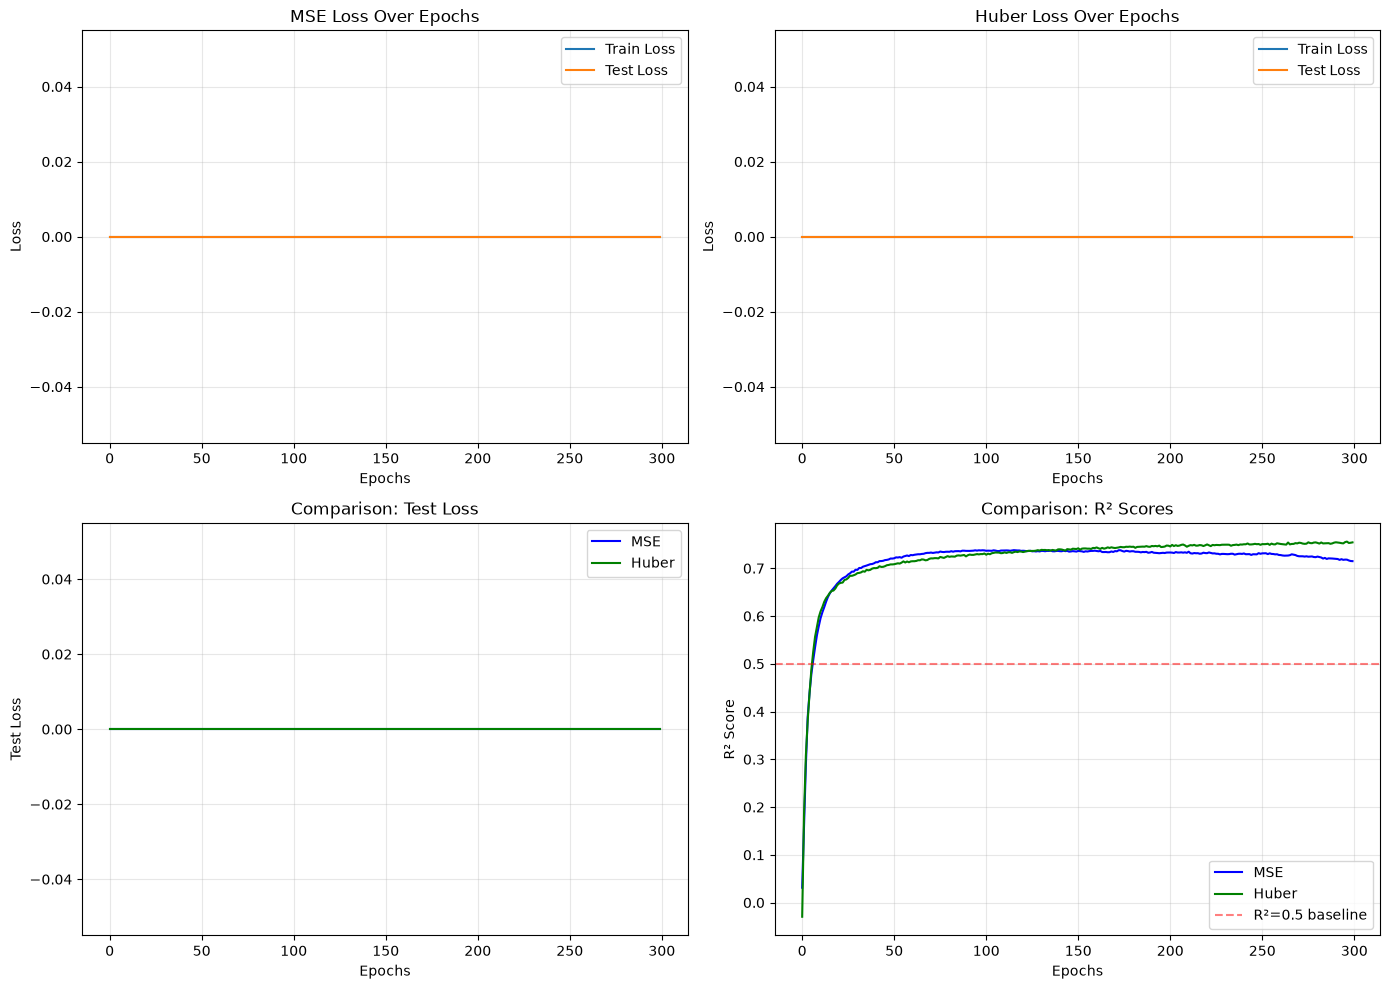

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot training and test losses for MSE
axes[0, 0].plot(train_losses_mse, label='Train Loss')
axes[0, 0].plot(test_losses_mse, label='Test Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('MSE Loss Over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot training and test losses for Huber
axes[0, 1].plot(train_losses_huber, label='Train Loss')
axes[0, 1].plot(test_losses_huber, label='Test Loss')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Huber Loss Over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Compare test losses
axes[1, 0].plot(test_losses_mse, label='MSE', color='blue')
axes[1, 0].plot(test_losses_huber, label='Huber', color='green')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Test Loss')
axes[1, 0].set_title('Comparison: Test Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Compare R² scores
axes[1, 1].plot(r2_scores_mse, label='MSE', color='blue')
axes[1, 1].plot(r2_scores_huber, label='Huber', color='green')
axes[1, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='R²=0.5 baseline')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('Comparison: R² Scores')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Final Evaluation

In [54]:
def evaluate_model(model, X_test, y_test, dataset_name):
    ''' 
    Model evaluation
    '''
    model.eval()
    X_test_t = torch.tensor(X_test, dtype = torch.float32)
    y_test_t = torch.tensor(y_test, dtype = torch.float32)

    with torch.no_grad():
        predictions = model(X_test_t).numpy()

    # Metrics 
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)

    # Calculate percentage error
    mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

    print(f"\n=== {dataset_name} Model Performance ===")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    
    return predictions

# Evaluate both models
mse_preds = evaluate_model(model_mse, X_test_np, y_test_np, "MSE")
mse_preds = evaluate_model(model_huber, X_test_np, y_test_np, "Huber")



=== MSE Model Performance ===
R² Score: 0.7150
Mean Absolute Error (MAE): 2320638.90
Mean Absolute Percentage Error (MAPE): 25.21%

=== Huber Model Performance ===
R² Score: 0.7542
Mean Absolute Error (MAE): 1910631.56
Mean Absolute Percentage Error (MAPE): 17.90%


### Save Models

In [55]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save the best models
torch.save(model_mse.state_dict(), MODEL_PATH / "house_price_model_mse.pth")
torch.save(model_huber.state_dict(), MODEL_PATH / "house_price_model_huber.pth")

print("\n✅ Models saved successfully!")
print(f"MSE model: {MODEL_PATH / 'house_price_model_mse.pth'}")
print(f"Huber model: {MODEL_PATH / 'house_price_model_huber.pth'}")

# Optionally save the preprocessor
import pickle
with open(MODEL_PATH / "preprocessor.pkl", 'wb') as f:
    pickle.dump(preprocessor, f)


✅ Models saved successfully!
MSE model: models\house_price_model_mse.pth
Huber model: models\house_price_model_huber.pth
